#  Hotel Booking Demand — Cancellation Analysis

##  Latar Belakang
Dataset ini berisi **119.391 data booking** dari dua tipe hotel
(City Hotel & Resort Hotel) di Portugal pada periode 2015–2017.
Tingkat pembatalan booking yang tinggi menjadi tantangan serius
bagi industri perhotelan karena berdampak langsung pada pendapatan.

##  Tujuan Analisis
Proyek ini bertujuan menjawab 3 pertanyaan bisnis:

**B1**. Bagaimana tren pembatalan booking dari waktu ke waktu — apakah ada musim atau bulan tertentu dengan lonjakan pembatalan yang signifikan?


**B2**. Channel pemesanan mana yang menghasilkan tingkat pembatalan tertinggi, dan bagaimana hubungannya dengan Average Daily Rate (ADR)?


**B3**. Bagaimana perbandingan profil tamu yang cancel vs tidak cancel — dilihat dari lead time, tipe tamu, dan lama menginap?

##  Tools yang Digunakan
- **Python** (Pandas, Matplotlib) — Data cleaning & EDA
- **Dataset:** [Hotel Booking Demand — Kaggle](https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand)

---

# Import Library & Load Data

In [100]:
import pandas as pd

In [101]:
import numpy as np
df = pd.read_csv("hotel_bookings.csv")



In [102]:
print ("Shape: ", df.shape)
print ("Column: ", df.columns)
print ("Info: ", df.info())

Shape:  (119390, 32)
Column:  Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel       

In [103]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


# Data Cleaning

In [104]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [105]:
print("Jumlah duplikat:", df.duplicated().sum())

Jumlah duplikat: 31994


In [106]:
df[['agent', 'company']] = df[['agent', 'company']].fillna(0)

In [107]:
df['country'] = df['country'].fillna('Unkown')

In [108]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [109]:
df.drop_duplicates(inplace=True)
print("Jumlah duplikat setelah penghapusan:", df.duplicated().sum())

Jumlah duplikat setelah penghapusan: 0


In [110]:
df['children'] = df['children'].fillna(0)
df['children'] = df['children'].replace(10, 0)
print(df['children'].unique())
print(df['adr'].describe())

[0. 1. 2. 3.]
count    87396.000000
mean       106.337246
std         55.013953
min         -6.380000
25%         72.000000
50%         98.100000
75%        134.000000
max       5400.000000
Name: adr, dtype: float64


In [111]:
print("Jumlah baris children = 10:")
print(df[df['children'] == 10].shape[0])

print("\nJumlah NaN di children:")
print(df['children'].isnull().sum())

Jumlah baris children = 10:
0

Jumlah NaN di children:
0


In [112]:
print("\nJumlah baris ADR negatif:")
print(df[df['adr'] < 0].shape[0])

print("\nJumlah baris ADR > 3000:")
print(df[df['adr'] > 3000].shape[0])

print("\nDetail baris ADR ekstrem:")
print(df[df['adr'] > 3000][['hotel','adr','adults',
      'children','stays_in_week_nights']])


Jumlah baris ADR negatif:
1

Jumlah baris ADR > 3000:
1

Detail baris ADR ekstrem:
            hotel     adr  adults  children  stays_in_week_nights
48515  City Hotel  5400.0       2       0.0                     1


In [113]:
adr_median = df['adr'].median()
print(f"Median ADR: {adr_median}")

Median ADR: 98.1


In [114]:
df.loc[df['adr'] > 3000, 'adr'] = adr_median
df.loc[df['adr'] < 0, 'adr'] = adr_median
print("ADR setelah penggantian nilai ekstrem:")
print(df['adr'].describe())

ADR setelah penggantian nilai ekstrem:
count    87396.000000
mean       106.277777
std         52.016743
min          0.000000
25%         72.000000
50%         98.100000
75%        134.000000
max        510.000000
Name: adr, dtype: float64


In [115]:
# Verifikasi hasil cleaning
print("=== CLEANING REPORT ===")
print(f"Shape setelah cleaning: {df.shape}")
print(f"\nSisa missing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
print(f"\nNilai unik children: {sorted(df['children'].unique())}")
print(f"\nADR min: {df['adr'].min():.2f}")
print(f"ADR max: {df['adr'].max():.2f}")
print(f"ADR median: {df['adr'].median():.2f}")

=== CLEANING REPORT ===
Shape setelah cleaning: (87396, 32)

Sisa missing values:
Series([], dtype: int64)

Nilai unik children: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0)]

ADR min: 0.00
ADR max: 510.00
ADR median: 98.10


# EDA

## B1. Bagaimana tren pembatalan booking dari waktu ke waktu — apakah ada musim atau bulan tertentu dengan lonjakan pembatalan yang signifikan?

In [116]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a mapping from month names (full or abbreviated) to their numerical representation
month_name_to_num = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
    'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12,
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
    'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}

# Apply this mapping to create the numerical month column
df['arrival_date_month_num'] = df['arrival_date_month'].map(month_name_to_num)

# Create 'month_year' column for chronological sorting and better visualization
df['month_year'] = df['arrival_date_year'].astype(str) + '-' + df['arrival_date_month_num'].astype(str).str.zfill(2)

# Sort by year and month
df_sorted = df.sort_values(by=['arrival_date_year', 'arrival_date_month_num'])

# Calculate total bookings and cancellations per month
monthly_cancellations = df_sorted.groupby('month_year')['is_canceled'].agg(total_bookings='count', canceled_bookings='sum').reset_index()

# Calculate cancellation rate
monthly_cancellations['cancellation_rate'] = (monthly_cancellations['canceled_bookings'] / monthly_cancellations['total_bookings']) * 100

# Extract year and month name for the table display
monthly_cancellations['year'] = monthly_cancellations['month_year'].apply(lambda x: x.split('-')[0])
monthly_cancellations['month_name'] = monthly_cancellations['month_year'].apply(lambda x: pd.to_datetime(x.split('-')[1], format='%m').strftime('%B'))

# Display the results in the requested table format
print("Cancellation Rate per Bulan (diurutkan):")
display(monthly_cancellations[['year', 'month_name', 'total_bookings', 'canceled_bookings', 'cancellation_rate']])

Cancellation Rate per Bulan (diurutkan):


,year,month_name,total_bookings,canceled_bookings,cancellation_rate
0,2015,July,1674,512,30.585424
1,2015,August,2453,571,23.277619
2,2015,September,2839,566,19.936597
3,2015,October,2700,440,16.296296
4,2015,November,1665,243,14.594595
5,2015,December,1982,372,18.768920
6,2016,January,1849,301,16.279070
7,2016,February,2806,528,18.816821
8,2016,March,3831,886,23.127121
9,2016,April,3770,1014,26.896552


### Grafik Cancellation Rate Waktu ke Waktu

In [117]:
# Calculate annual cancellation rate
annual_cancellations = monthly_cancellations.groupby('year').agg(
    total_bookings=('total_bookings', 'sum'),
    canceled_bookings=('canceled_bookings', 'sum')
).reset_index()

annual_cancellations['cancellation_rate'] = (annual_cancellations['canceled_bookings'] / annual_cancellations['total_bookings']) * 100

print("Rata-rata Cancellation Rate per Tahun:")
display(annual_cancellations[['year', 'total_bookings', 'canceled_bookings', 'cancellation_rate']])

Rata-rata Cancellation Rate per Tahun:


,year,total_bookings,canceled_bookings,cancellation_rate
0,2015,13313,2704,20.310974
1,2016,42391,11208,26.439574
2,2017,31692,10113,31.910261


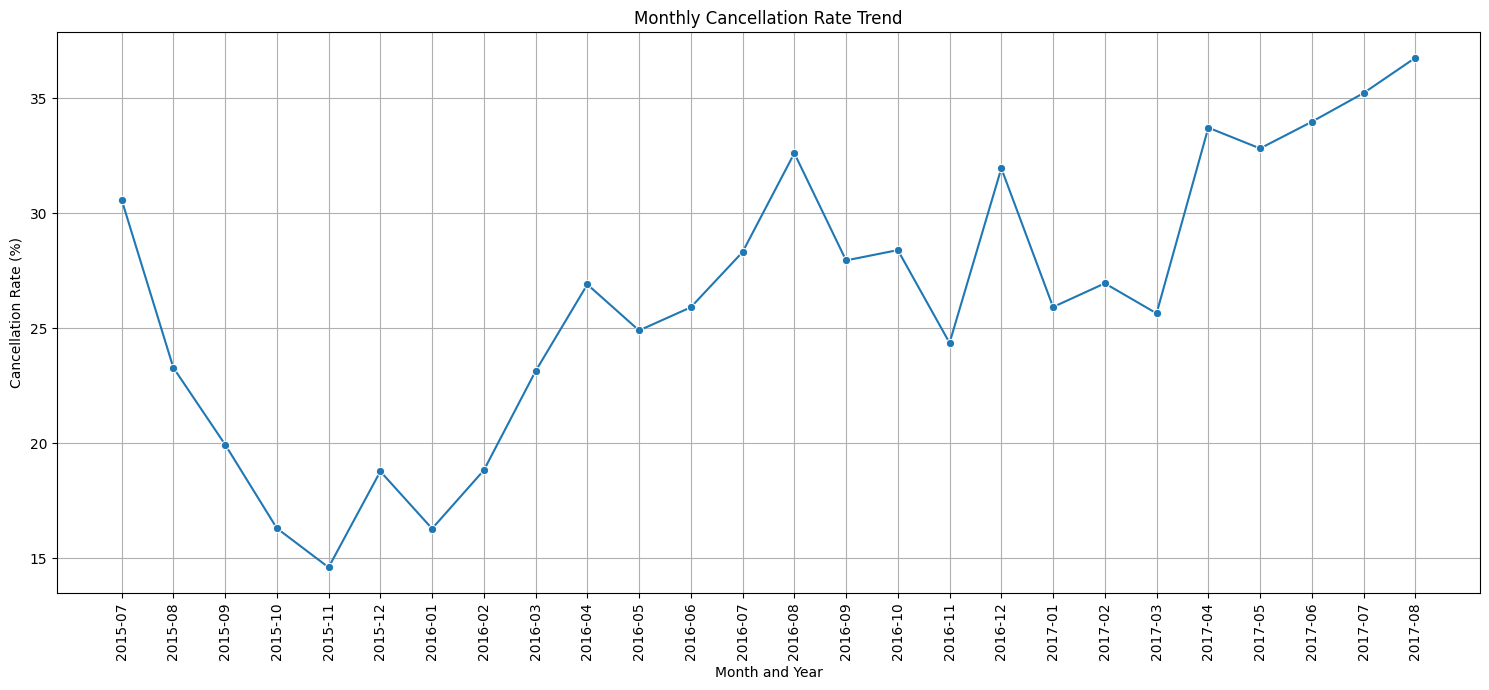

In [118]:
plt.figure(figsize=(15, 7))
sns.lineplot(x='month_year', y='cancellation_rate', data=monthly_cancellations, marker='o')
plt.title('Monthly Cancellation Rate Trend')
plt.xlabel('Month and Year')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=90)
plt.grid(True)
plt.tight_layout()
plt.show()

- Dapat disimpulkan bahwa cancellation rate terus meningkat dari tahun ke tahun.
- cancellation rate tertinggi terjadi pada bulan Juli - Agustus yang dimana pada bulan tersebut juga terjadi booking terbanyak **(High Volume, High Risk Period)**.


## B2. Channel pemesanan mana yang menghasilkan tingkat pembatalan tertinggi, dan bagaimana hubungannya dengan Average Daily Rate (ADR)?

In [119]:
market_segment_summary = df.groupby('market_segment').agg(
    total_bookings=('is_canceled', 'count'),
    canceled_bookings=('is_canceled', 'sum'),
    avg_adr=('adr', 'mean')
).reset_index()

market_segment_summary['cancellation_rate'] = (market_segment_summary['canceled_bookings'] / market_segment_summary['total_bookings']) * 100

market_segment_summary = market_segment_summary.sort_values(by='cancellation_rate', ascending=False)

print("Analisis Pembatalan dan ADR berdasarkan Market Segment:")
display(market_segment_summary[['market_segment', 'total_bookings', 'canceled_bookings', 'cancellation_rate', 'avg_adr']])

Analisis Pembatalan dan ADR berdasarkan Market Segment:


,market_segment,total_bookings,canceled_bookings,cancellation_rate,avg_adr
7,Undefined,2,2,100.000000,15.000000
6,Online TA,51618,18245,35.346197,118.171606
4,Groups,4942,1335,27.013355,74.885425
0,Aviation,227,45,19.823789,100.170396
5,Offline TA/TO,13889,2063,14.853481,81.382457
3,Direct,11804,1737,14.715351,116.579429
1,Complementary,702,88,12.535613,3.049245
2,Corporate,4212,510,12.108262,68.151246


### Cancellation Rate vs ADR per Market Segmen

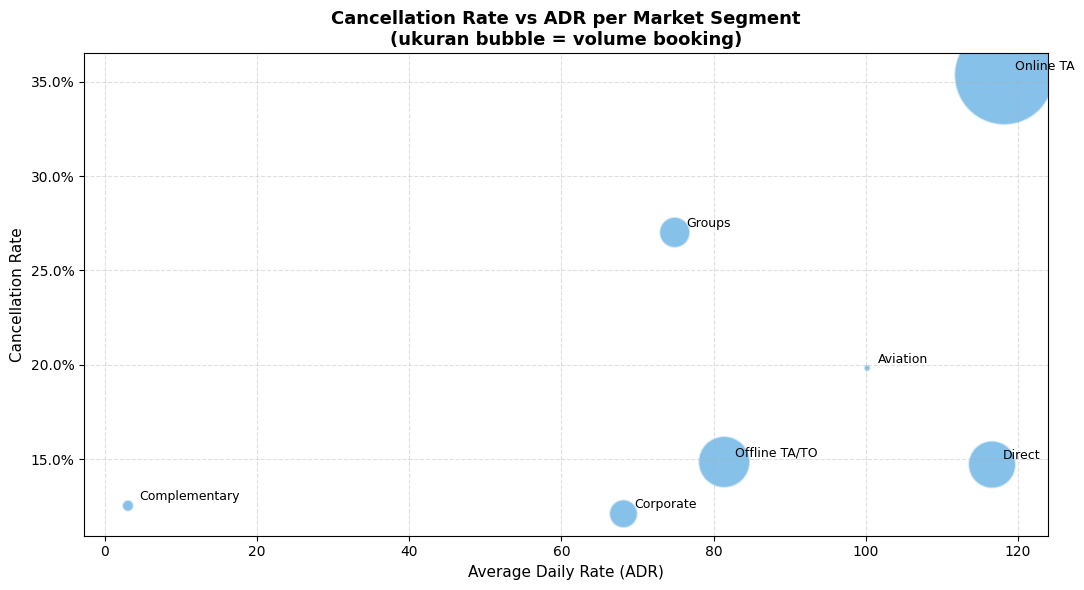

In [120]:
import matplotlib.ticker as mtick

# Filter Undefined
viz_data = market_segment_summary[
    market_segment_summary['market_segment'] != 'Undefined'
].copy()

fig, ax = plt.subplots(figsize=(11, 6))

scatter = ax.scatter(
    viz_data['avg_adr'],
    viz_data['cancellation_rate'],
    s=viz_data['total_bookings'] / 10,  # ukuran bubble = volume booking
    alpha=0.6,
    color='#3498DB',
    edgecolors='white',
    linewidth=1.5
)

# Label setiap bubble
for _, row in viz_data.iterrows():
    ax.annotate(row['market_segment'],
                (row['avg_adr'], row['cancellation_rate']),
                textcoords="offset points",
                xytext=(8, 4), fontsize=9)

ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel('Average Daily Rate (ADR)', fontsize=11)
ax.set_ylabel('Cancellation Rate', fontsize=11)
ax.set_title('Cancellation Rate vs ADR per Market Segment\n(ukuran bubble = volume booking)',
             fontsize=13, fontweight='bold')
ax.grid(linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('b2_channel_analysis.png', dpi=150)
plt.show()

Yang perlu diperhatikan adalah segmen Online TA. Segmen ini menghasilkan pemesanan terbanyak, angka pembatalannya juga sangat besar. Pihak hotel sebaiknya mulai menerapkan kebijakan baru, seperti sistem non-refundable atau denda pembatalan, untuk mengantisipasi tingginya angka pembatalan dari platform tersebut.

# B3. Bagaimana perbandingan profil tamu yang cancel vs tidak cancel — dilihat dari lead time, tipe tamu, dan lama menginap?

In [121]:
# 1. Buat kolom total_stays
df['total_stays'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

# 2. Tabel Perbandingan Profil: Groupby is_canceled dan agregasi
profile_comparison = df.groupby('is_canceled').agg(
    avg_lead_time=('lead_time', 'mean'),
    avg_total_stays=('total_stays', 'mean'),
    most_common_customer_type=('customer_type', lambda x: x.mode()[0])
).reset_index()

print("Tabel 1: Perbandingan Profil Tamu (0 = Tidak Cancel, 1 = Cancel)")
display(profile_comparison)



Tabel 1: Perbandingan Profil Tamu (0 = Tidak Cancel, 1 = Cancel)


,is_canceled,avg_lead_time,avg_total_stays,most_common_customer_type
0,0,70.099588,3.487557,Transient
1,1,105.719251,4.008117,Transient


In [122]:
# 3. Tabel Kedua: Cancellation rate per customer_type
customer_type_analysis = df.groupby('customer_type').agg(
    total_bookings=('is_canceled', 'count'),
    canceled_bookings=('is_canceled', 'sum')
).reset_index()

customer_type_analysis['cancellation_rate'] = (customer_type_analysis['canceled_bookings'] / customer_type_analysis['total_bookings']) * 100
customer_type_analysis = customer_type_analysis.sort_values(by='cancellation_rate', ascending=False)

print("\nTabel 2: Cancellation Rate per Customer Type")
display(customer_type_analysis)


Tabel 2: Cancellation Rate per Customer Type


,customer_type,total_bookings,canceled_bookings,cancellation_rate
2,Transient,71986,21672,30.105854
0,Contract,3139,512,16.310927
3,Transient-Party,11727,1787,15.238339
1,Group,544,54,9.926471


### Chart Profil tamu yang cancel vs tidak cancel

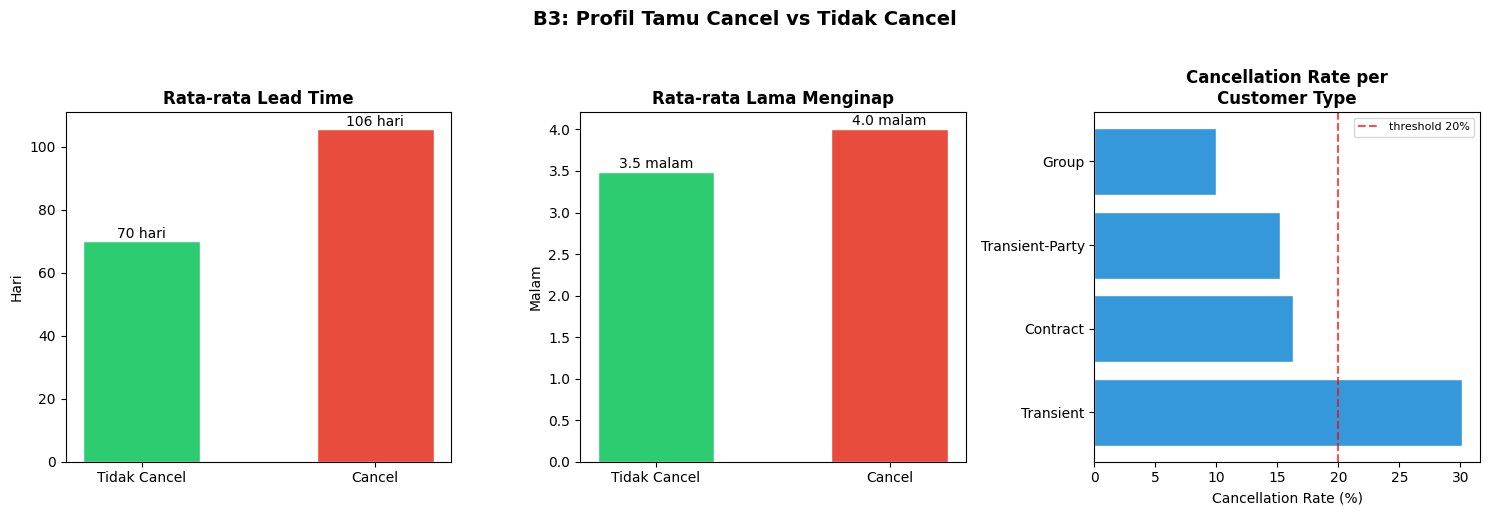

In [123]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Chart 1 — Lead Time Comparison
categories = ['Tidak Cancel', 'Cancel']
lead_times = profile_comparison['avg_lead_time'].values
bars1 = axes[0].bar(categories, lead_times,
                    color=['#2ECC71', '#E74C3C'],
                    width=0.5, edgecolor='white')
axes[0].set_title('Rata-rata Lead Time', fontweight='bold')
axes[0].set_ylabel('Hari')
for bar, val in zip(bars1, lead_times):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f'{val:.0f} hari', ha='center', fontsize=10)

# Chart 2 — Total Stays Comparison
stays = profile_comparison['avg_total_stays'].values
bars2 = axes[1].bar(categories, stays,
                    color=['#2ECC71', '#E74C3C'],
                    width=0.5, edgecolor='white')
axes[1].set_title('Rata-rata Lama Menginap', fontweight='bold')
axes[1].set_ylabel('Malam')
for bar, val in zip(bars2, stays):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.05,
                 f'{val:.1f} malam', ha='center', fontsize=10)

# Chart 3 — Cancellation Rate per Customer Type
axes[2].barh(customer_type_analysis['customer_type'],
             customer_type_analysis['cancellation_rate'],
             color='#3498DB', edgecolor='white')
axes[2].set_title('Cancellation Rate per\nCustomer Type', fontweight='bold')
axes[2].set_xlabel('Cancellation Rate (%)')
axes[2].axvline(x=20, color='red', linestyle='--',
                alpha=0.7, label='threshold 20%')
axes[2].legend(fontsize=8)

plt.suptitle('B3: Profil Tamu Cancel vs Tidak Cancel',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('b3_customer_profile.png', dpi=150)
plt.show()

- semakin jauh lead time, semakin besar kemungkinan perubahan rencana oleh tamu
- rata rata tamu yang melakukan cancel menginap lebih lama, ini harus menjadi perhatian lebih oleh hotel karena semakin lama menginap revenue semakin banyak


**hotel bisa menerapkan reschedule 1x dan cancellation fee untuk mengurangi cancellation rate tamu**


# B4 Kesimpulan & Rekomendasi


**B1 - Tren Waktu**

Cancellation rate meningkat tiap tahun (2015: ~20% → 2017: ~31%). Puncaknya di Juli–Agustus yang justru high season.

Rekomendasi: Terapkan early bird non-refundable rate khusus Juli–Agustus — tamu yang booking jauh hari dapat harga lebih murah tapi tidak bisa di-cancel

**B2 - Channel Pemesanan**

Online TA memiliki cancellation rate tertinggi (35%) sekaligus volume
booking terbesar dan ADR tertinggi

Rekomendasi: Negosiasi ulang kontrak dengan platform Online TA untuk terapkan kebijakan deposit minimum 20–30% saat booking

**B3 - Profil Tamu**

Tamu yang cancel rata-rata memesan 105 hari lebih awal dan berencana menginap lebih lama, artinya potensi revenue yang hilang lebih besar

Rekomendasi: Terapkan cancellation fee berjenjang berdasarkan lead time: semakin jauh dari tanggal menginap saat cancel, fee semakin kecil. Plus reschedule gratis 1x